## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [8]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [9]:
out_dir = project_dir / "results"

if not os.path.exists(out_dir):
    os.makedirs(out_dir)

## LOCAL PARAMETERS

In [10]:
method_infomap = 'nearest_neighbor_limit' # 'score_map', 'nearest_neighbor_limit'

## LOAD

In [11]:
# load tile trajectories
dat_traj_dict = pickle.load(open(project_dir / "results" / "dat_traj_dict", "rb"))

# load infomap
if method_infomap == 'score_map':
    dat_infomap_optmap = pickle.load(open(out_dir / 'dat_infomap_optmap', "rb"))
    dat_infomap_randmap = pickle.load(open(out_dir / 'dat_infomap_randmap', "rb"))
elif method_infomap == 'nearest_neighbor_limit':
    dat_infomap_optmap = pickle.load(open(out_dir / 'dat_infomap_optmap_nn', "rb"))
    dat_infomap_randmap = pickle.load(open(out_dir / 'dat_infomap_randmap_nn', "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [12]:
# FULL PILOT BATCH: 10 pi_level, 6 traj for one mouse x 2 + 5 random trajectories (170 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse_3 = [((1,3,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
job_list_mouse_4 = [((1,4,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch_optmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_optmap)

170

In [13]:
# RANDOM MAP BATCH: 10 pi_level, 2 mice x 5 random maps + 5 random trajectories x 5 random maps (350 jobs)
traj_seed_list = np.arange(5)
map_seed_list = np.arange(5)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,traj_seed,-1), pi_lev, map_seed) for pi_lev in pi_level_list for traj_seed in traj_seed_list for map_seed in map_seed_list]
job_list_mouse_3 = [((1,3,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]
job_list_mouse_4 = [((1,4,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]

# pack
job_batch_randmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_randmap)

350

## PREP
### setting up belief distribution propagation

In [14]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)
xy_tile_all = np.array([(hex_0_grid[y,x], hex_1_grid[y,x]) for (x,y), s in xy_s_dict.items()])
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## FIGURE: map

### plot: optimization in action

In [15]:
load_dir = project_dir / "results" / "data_optmap"
job_id = 93 # 105,46; 99,41; 93,36; 87,31
label = 'optmap, mouse 3'

# load one job
job = job_batch_optmap[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
map_iter, mapsize_iter, score_map_iter, score_iter = load_maps_from_one_job(load_dir, job, n_edges)

# select iters to plot
score_tar = [.995, .99, .7, .05]
iter_select = np.abs(score_iter[:,None] - np.array(score_tar)[None]).argmin(0)
map_select = [map_iter[x] for x in iter_select]
mapsize_select = [mapsize_iter[x] for x in iter_select]
score_select = [round(score_iter[x], 2) for x in iter_select]
mapsize_select

[582, 253, 67, 33]

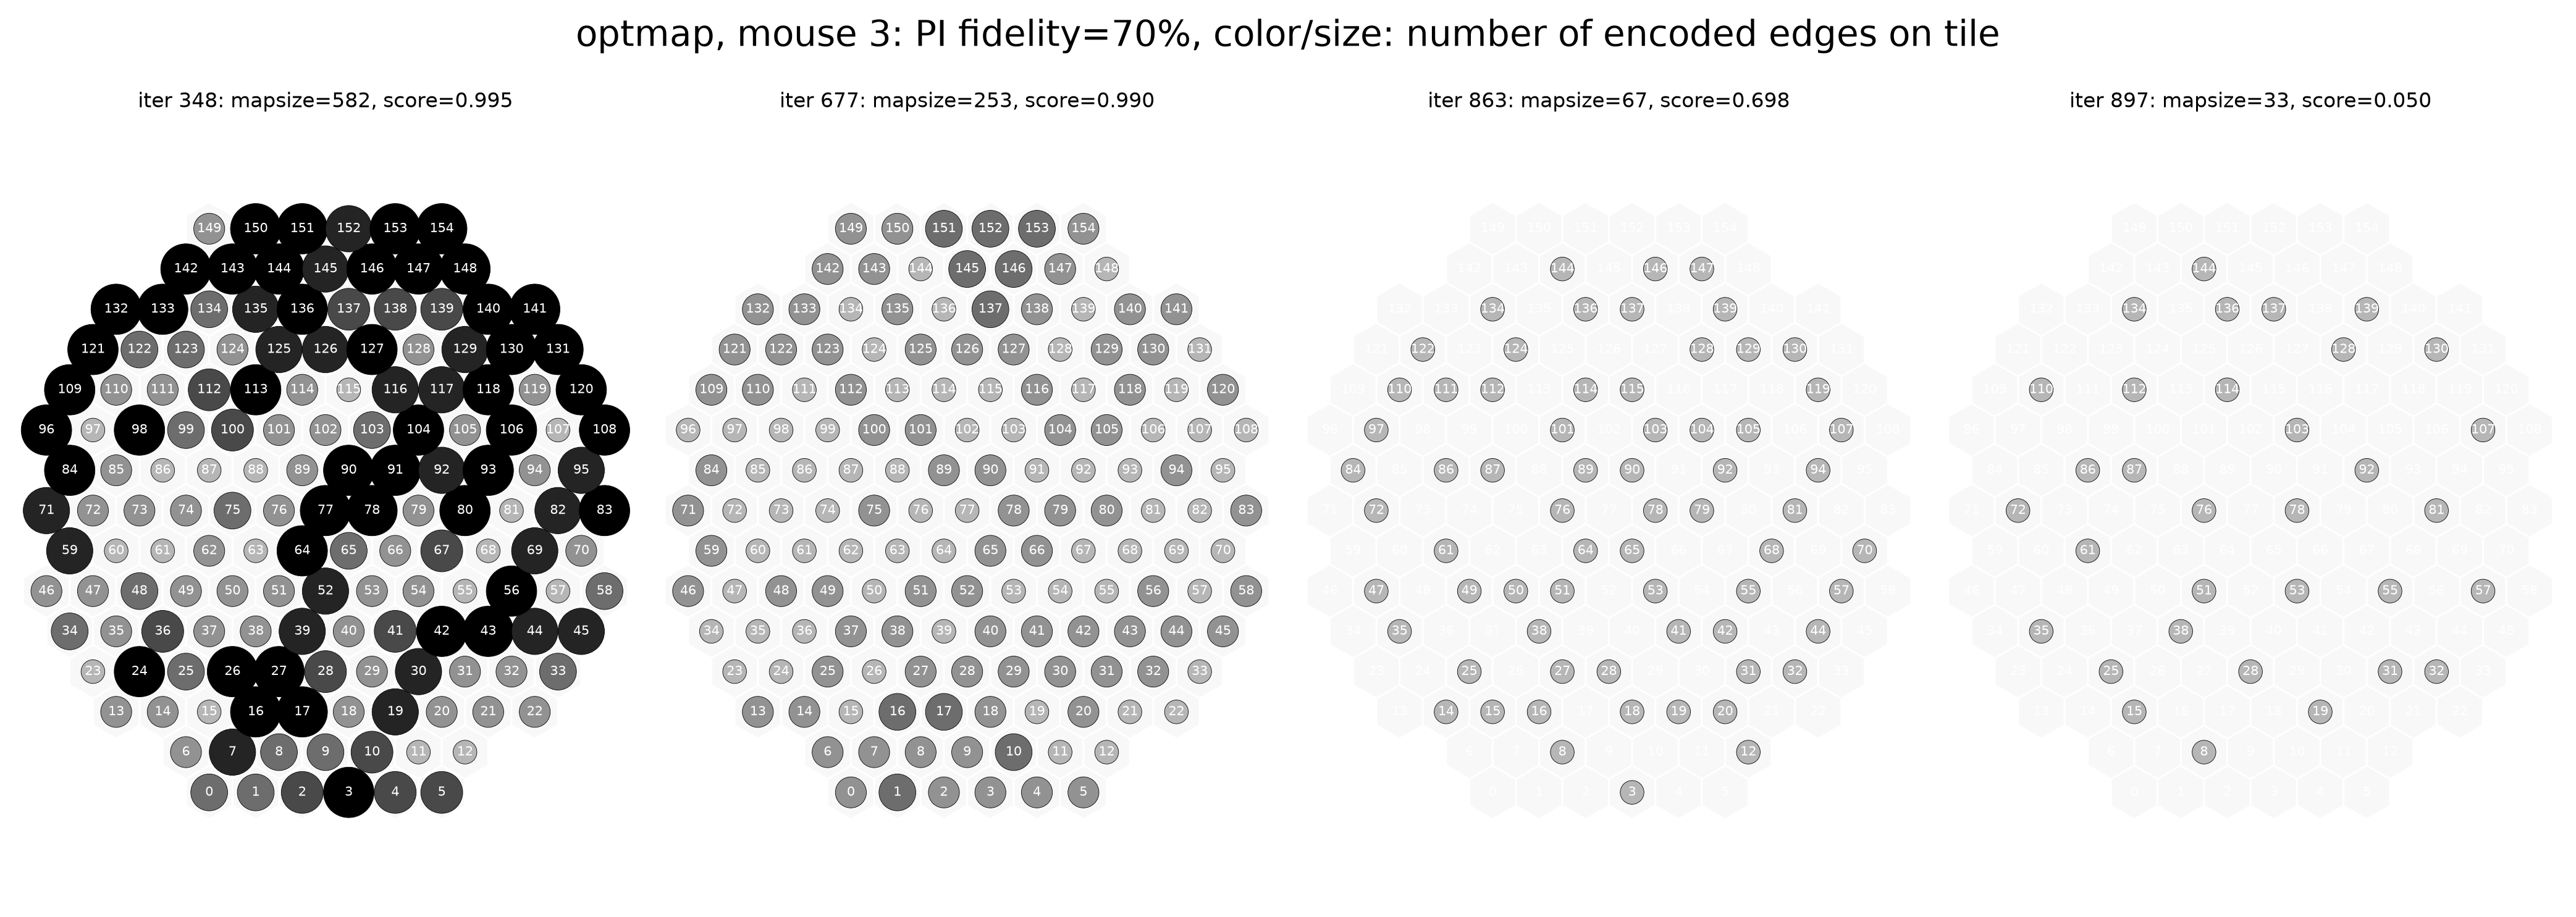

In [16]:
# plot
plt.figure(figsize=(14,5), dpi=300)
plt.suptitle(f"{label}: PI fidelity=70%, color/size: number of encoded edges on tile", fontsize=14)

for i, (iter, map, mapsize, score) in enumerate(zip(iter_select, map_select, mapsize_select, score_select)):
    # load
    map, score_map, score, n_edges_map = load_one_map(mapsize, map_iter, mapsize_iter, score_iter, score_map_iter, e_sh_arr, sh_dz_arr)

    # plot
    plt.subplot(1,4,i+1)
    plt.title(f"iter {iter}: mapsize={mapsize}, score={score:.3f}", fontsize=8)
    plt.scatter(hex_0_all, hex_1_all, marker='h', c='lightgray', s=400, edgecolor='none', alpha=.15)
    plt.scatter(hex_0_all, hex_1_all, c=n_edges_map, cmap='binary', marker='o', s=(120*n_edges_map+50)*(n_edges_map>0)*.5, vmin=-1, vmax=6, edgecolor='k', lw=.2)

    for (x,y), s in xy_s_dict.items():
        plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='w', fontsize=5, ha='center', va='center')

    # setting
    plt.axis('off')
    plt.axis('equal')
plt.tight_layout()

### plot: test one infomap

In [17]:
load_dir = project_dir / "results" / "data_optmap"
job_id = 93 # 105,46; 99,41; 93,36; 87,31
mapsize = 67  # 13,14; 39,41; 68,71
method = 'nearest_neighbor_limit' # 'score_map', 'nearest_neighbor_limit'

# load one job
job = job_batch_optmap[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
map_iter, mapsize_iter, score_map_iter, score_iter = load_maps_from_one_job(load_dir, job, n_edges)

# load one map so that score≈0.7
map, score_map, score, n_edges_map = load_one_map(mapsize, map_iter, mapsize_iter, score_iter, score_map_iter, e_sh_arr, sh_dz_arr)

# get diffusion radius
# score_map = np.ones_like(score_map) * (1-1e-6)
# sigma_tile = get_sigma_tile(score_map, xy_tile_all)
sigma_tile = get_sigma_tile(score_map, xy_tile_all, method=method_infomap)

# get tile locality, ambiguity, identifiability
L_mat, A_mat, I_mat_local = get_locality_ambiguity_identifiability(map, sigma_tile, xy_tile_all, sh_dz_arr, e_sh_arr)

# get infomap
infomap, info_mean = get_infomap(L_mat, A_mat, I_mat_local, s_top, n_edges_map, mapsize, score_map, method=method_infomap)

# print
info_mean

0.4078024513296944

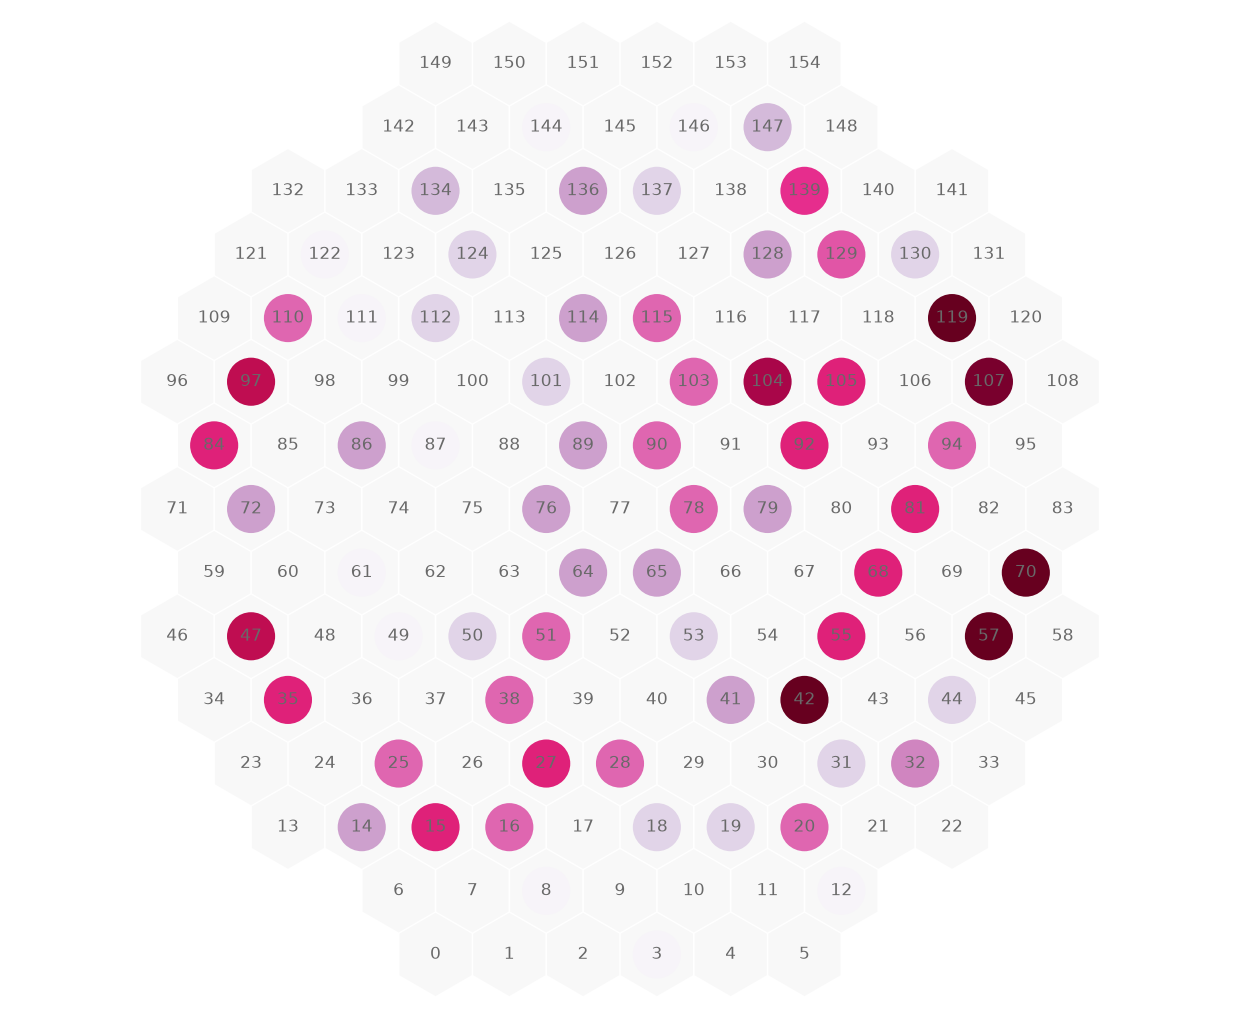

In [18]:
# plot
plt.figure(figsize=(6.3,5.2), dpi=200)
# plt.title(f'mouse {mouse_id}, sessions: {2}; top half occupied: {len(s_top)} tiles')

# map
plt.scatter(hex_0_all, hex_1_all, marker='h', c='lightgray', s=900, edgecolor='none', alpha=.15)

plt.scatter(hex_0_all, hex_1_all, c=infomap, cmap='PuRd', marker='o', s=300*n_edges_map, vmin=0, vmax=1, edgecolor='none')
# plt.colorbar()

for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')

# setting
plt.axis('off')
plt.axis('equal')
plt.tight_layout()

### plot: infomap

In [19]:
# init
mapsize = 67
label_list = ['optmap, mouse', 'optmap, rotated mouse', 'optmap, random walk', 'randmap, mouse', 'randmap, random walk']
method_list = ['optmap', 'optmap', 'optmap', 'randmap', 'randmap']
job_id_list = [93, 94, 36, 286, 176]

# iter
infomap_list = []
info_mean_list = []
score_list = []
n_edges_map_list = []
for method, job_id in zip(method_list, job_id_list):
    # load
    if method == 'optmap':
        mapsize_iter, infomap_all, info_mean_all = dat_infomap_optmap
        load_dir = project_dir / "results" / "data_optmap"
        job = job_batch_optmap[job_id]
    elif method == 'randmap':
        mapsize_iter, infomap_all, info_mean_all = dat_infomap_randmap
        load_dir = project_dir / "results" / "data_randmap"
        job = job_batch_randmap[job_id]
    
    # get map
    s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
    map_iter, mapsize_iter, score_map_iter, score_iter = load_maps_from_one_job(load_dir, job, n_edges)
    map, score_map, score, n_edges_map = load_one_map(mapsize, map_iter, mapsize_iter, score_iter, score_map_iter, e_sh_arr, sh_dz_arr)
    score_list.append(score)
    n_edges_map_list.append(n_edges_map)

    # get infomap
    infomap = infomap_all[job_id-1, mapsize_iter.index(mapsize)]
    info_mean = info_mean_all[job_id-1, mapsize_iter.index(mapsize)]
    infomap_list.append(infomap)
    info_mean_list.append(info_mean)

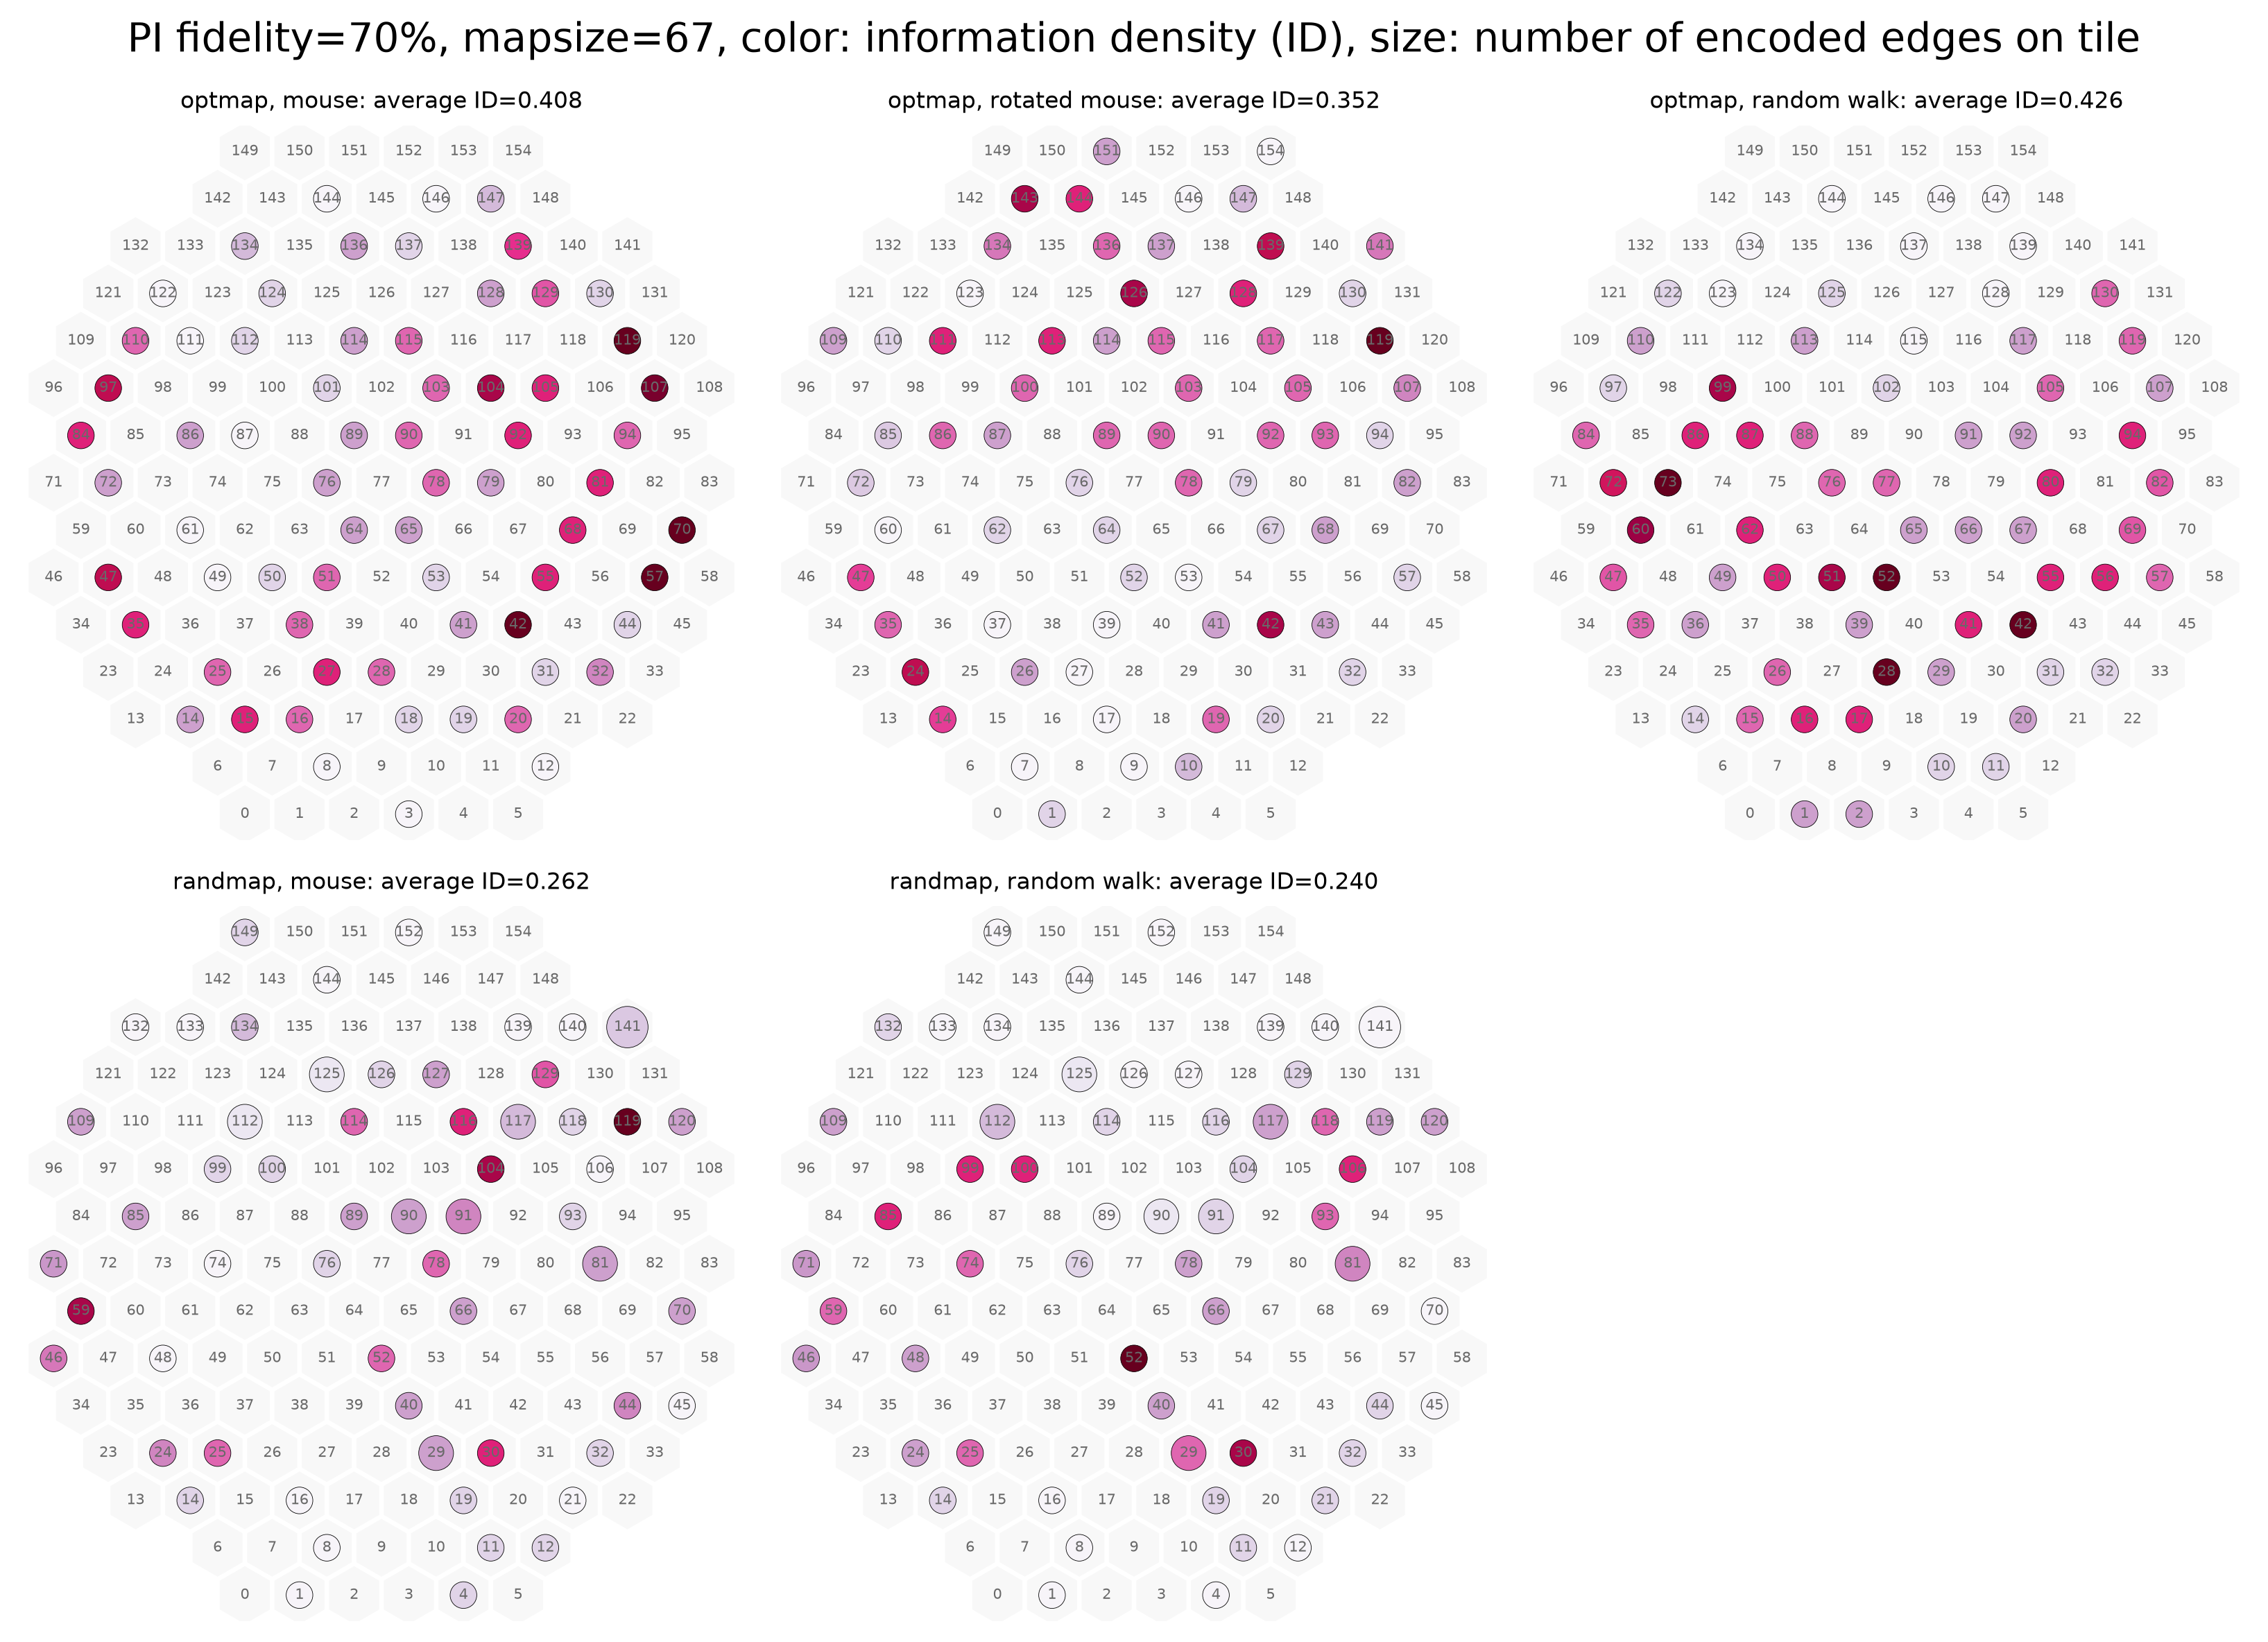

In [20]:
# plot
plt.figure(figsize=(11,8), dpi=300)
plt.suptitle(f"PI fidelity=70%, mapsize={mapsize}, color: information density (ID), size: number of encoded edges on tile", fontsize=14)
for i, (label, infomap, info_mean, score, n_edges_map) in enumerate(zip(label_list, infomap_list, info_mean_list, score_list, n_edges_map_list)):

    # plot
    plt.subplot(2,3,i+1)
    plt.title(f"{label}: average ID={info_mean:.3f}", fontsize=8)
    plt.scatter(hex_0_all, hex_1_all, marker='h', c='lightgray', s=400, edgecolor='none', alpha=.15)
    plt.scatter(hex_0_all, hex_1_all, c=infomap, cmap='PuRd', marker='o', s=(120*n_edges_map+50)*(n_edges_map>0)*.5, vmin=0, vmax=1, edgecolor='k', lw=.2)

    for (x,y), s in xy_s_dict.items():
        plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=5, ha='center', va='center')

    # setting
    plt.axis('off')
    plt.axis('equal')
plt.tight_layout()

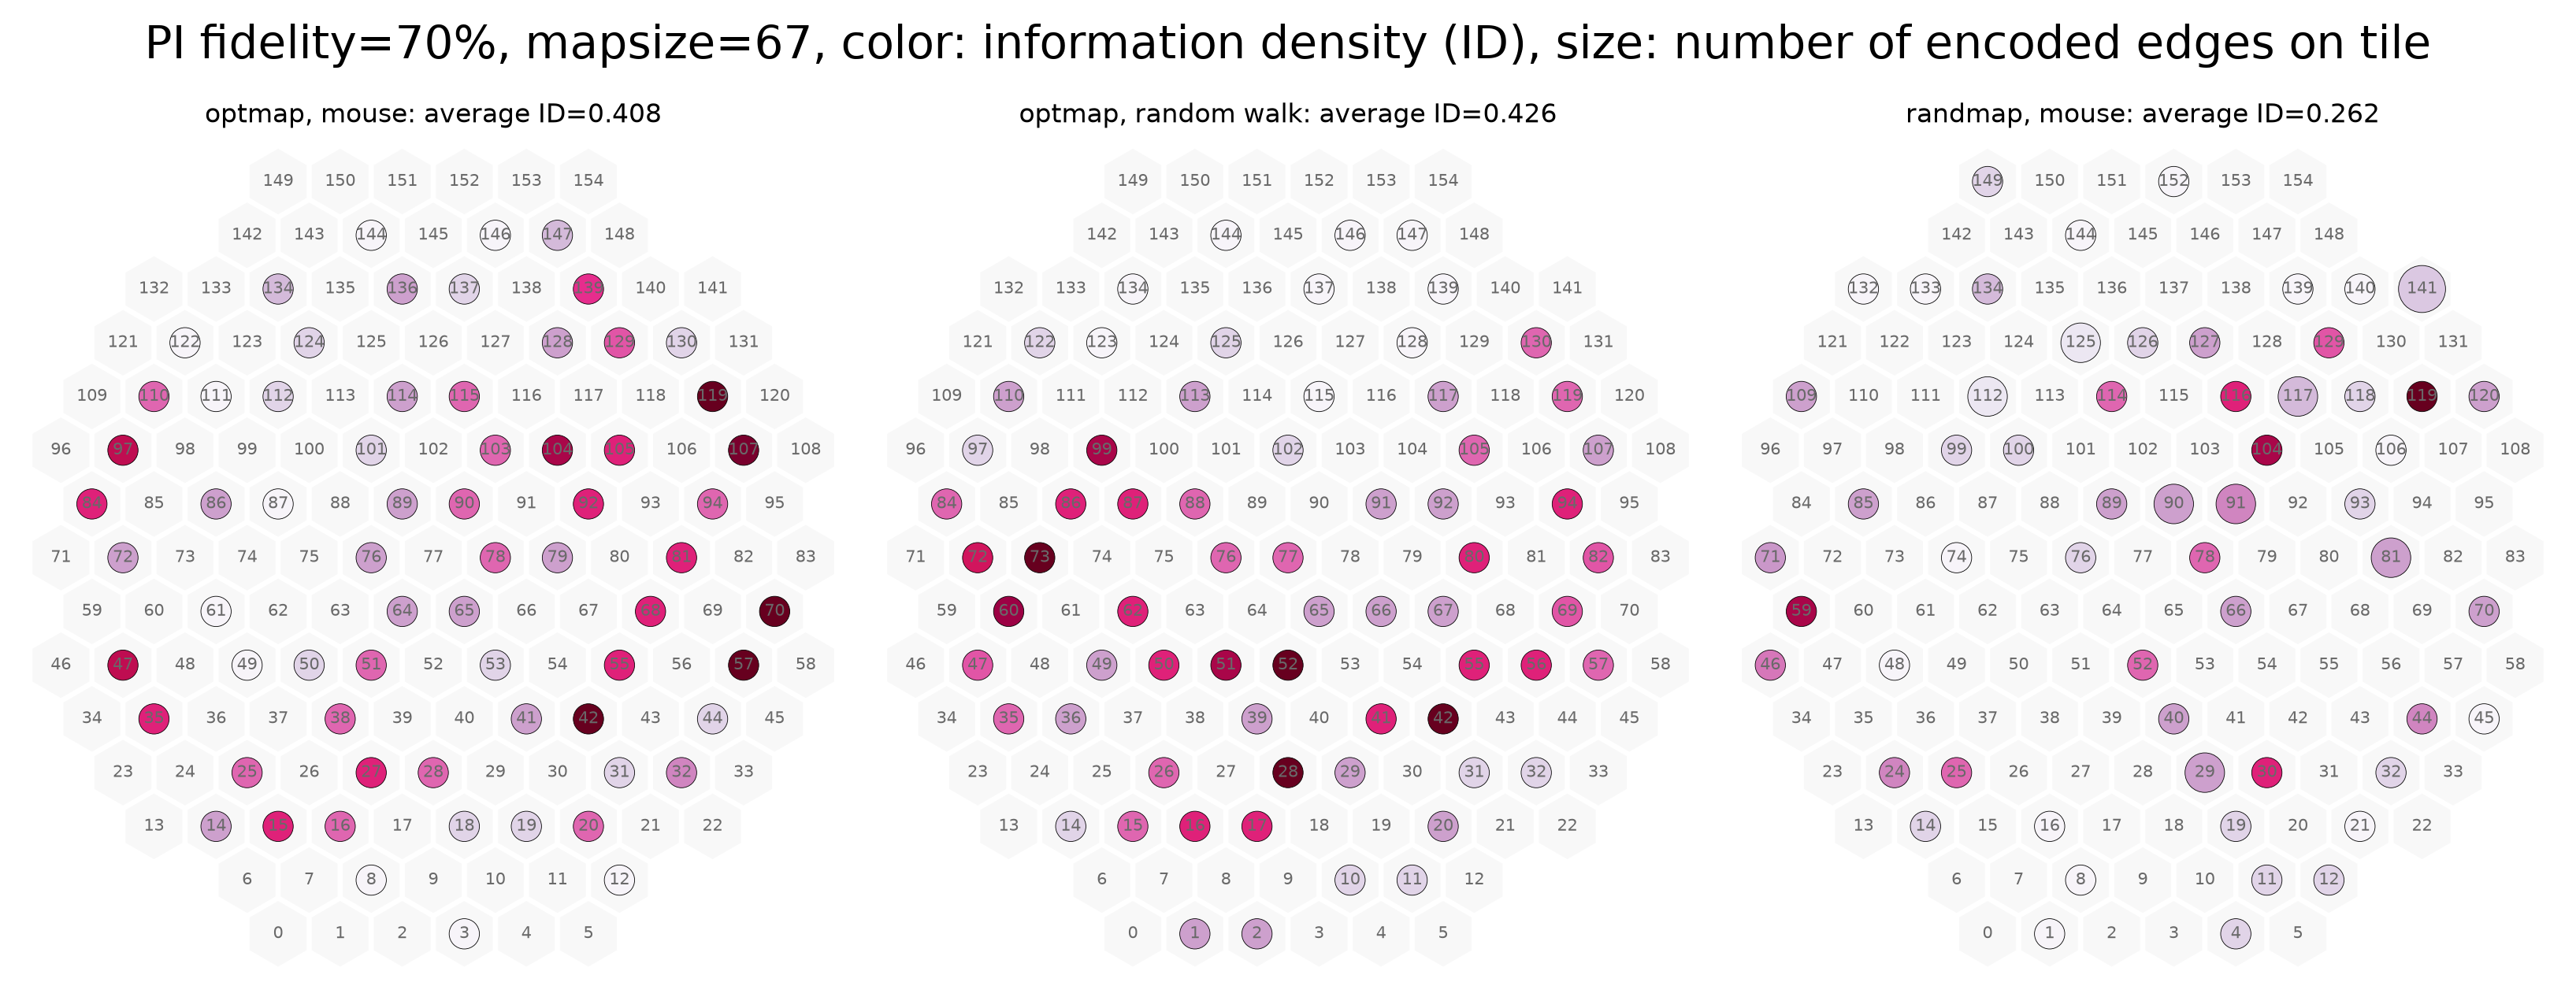

In [21]:
# plot
plt.figure(figsize=(11,8), dpi=300)
plt.suptitle(f"PI fidelity=70%, mapsize={mapsize}, color: information density (ID), size: number of encoded edges on tile", fontsize=14)
j = 0
for i, (label, infomap, info_mean, score, n_edges_map) in enumerate(zip(label_list, infomap_list, info_mean_list, score_list, n_edges_map_list)):
    if i in [1,4]: continue
    j += 1

    # plot
    plt.subplot(2,3,j)
    plt.title(f"{label}: average ID={info_mean:.3f}", fontsize=8)
    plt.scatter(hex_0_all, hex_1_all, marker='h', c='lightgray', s=400, edgecolor='none', alpha=.15)
    plt.scatter(hex_0_all, hex_1_all, c=infomap, cmap='PuRd', marker='o', s=(120*n_edges_map+50)*(n_edges_map>0)*.5, vmin=0, vmax=1, edgecolor='k', lw=.2)

    for (x,y), s in xy_s_dict.items():
        plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=5, ha='center', va='center')

    # setting
    plt.axis('off')
    plt.axis('equal')
plt.tight_layout()

In [31]:
n_edges_map.max()

3

In [36]:
score_list

[0.697555, 0.655895, 0.674358, 0.218064, 0.029135]

## FIGURE: stat

### prep: targeted mapsizes

In [22]:
# prep: score tensor for unrotated mouse (optmap)
job_selected = [x for x,((y,z,w),u) in job_batch_optmap.items() if w==0]
out_dir = project_dir / "results" / "data_optmap"
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_optmap[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(2,10,-1)
score_tensor_unrot = np.transpose(score_tensor, (1,0,2))[:,:,::-1]

# get mapsize for score≈0.7
score_tar = .7
mapsize_arr = np.argmin(np.abs(score_tensor_unrot-score_tar), axis=-1)
mapsize_list = np.around(mapsize_arr.mean(1)).astype(int)

In [29]:
mapsize_list

array([194, 172, 156, 142, 127, 110,  92,  67,  38,  12])

### prep: infomation density array

In [23]:
# init
label_list = ['optmap, mouse', 'optmap, rotated mouse', 'optmap, random walk', 'randmap, mouse', 'randmap, random walk']
info_tensor_list = []

In [24]:
# load
mapsize_iter, infomap_all, info_mean_all = dat_infomap_optmap
info_mean_all[np.isnan(info_mean_all)] = 0

# 'optmap, mouse'
job_id_select = np.array([x for x,((y,z,w),u) in job_batch_optmap.items() if w==0])
info_tensor = np.array(info_mean_all[job_id_select-1])[:,::-1].reshape(2,10,-1)
info_tensor = np.transpose(info_tensor, (1,0,2))
info_tensor_list.append(info_tensor)

# 'optmap, rotated mouse'
job_id_select = np.array([x for x,((y,z,w),u) in job_batch_optmap.items() if w>0])
info_tensor = np.array(info_mean_all[job_id_select-1])[:,::-1].reshape(2,10,5,-1)
info_tensor = np.transpose(info_tensor, (1,0,2,3)).reshape(10,10,-1)
info_tensor_list.append(info_tensor)

# 'optmap, random walk'
job_id_select = np.arange(1,51)
info_tensor = np.array(info_mean_all[job_id_select-1])[:,::-1].reshape(10,5,-1)
info_tensor_list.append(info_tensor)

In [25]:
# load
mapsize_iter, infomap_all, info_mean_all = dat_infomap_randmap
info_mean_all[np.isnan(info_mean_all)] = 0

# 'randmap, mouse'
job_id_select = np.array([x for x,((y,z,w),u,v) in job_batch_randmap.items() if y==1])
info_tensor = np.array(info_mean_all[job_id_select-1])[:,::-1].reshape(2,10,-1)
info_tensor = np.transpose(info_tensor, (1,0,2))
info_tensor_list.append(info_tensor)

# 'randmap, random walk'
job_id_select = np.array([x for x,((y,z,w),u,v) in job_batch_randmap.items() if y==0])
info_tensor = np.array(info_mean_all[job_id_select-1])[:,::-1].reshape(10,25,-1)
info_tensor_list.append(info_tensor)

In [26]:
# iter
info_mean_list = []
info_ci_list = []

for info_tensor in info_tensor_list:
    info_ci, info_mean, _ = get_confidence_interval(info_tensor, axis=1)
    info_mean_list.append(info_mean)
    info_ci_list.append(info_ci)

### plot: heatmap

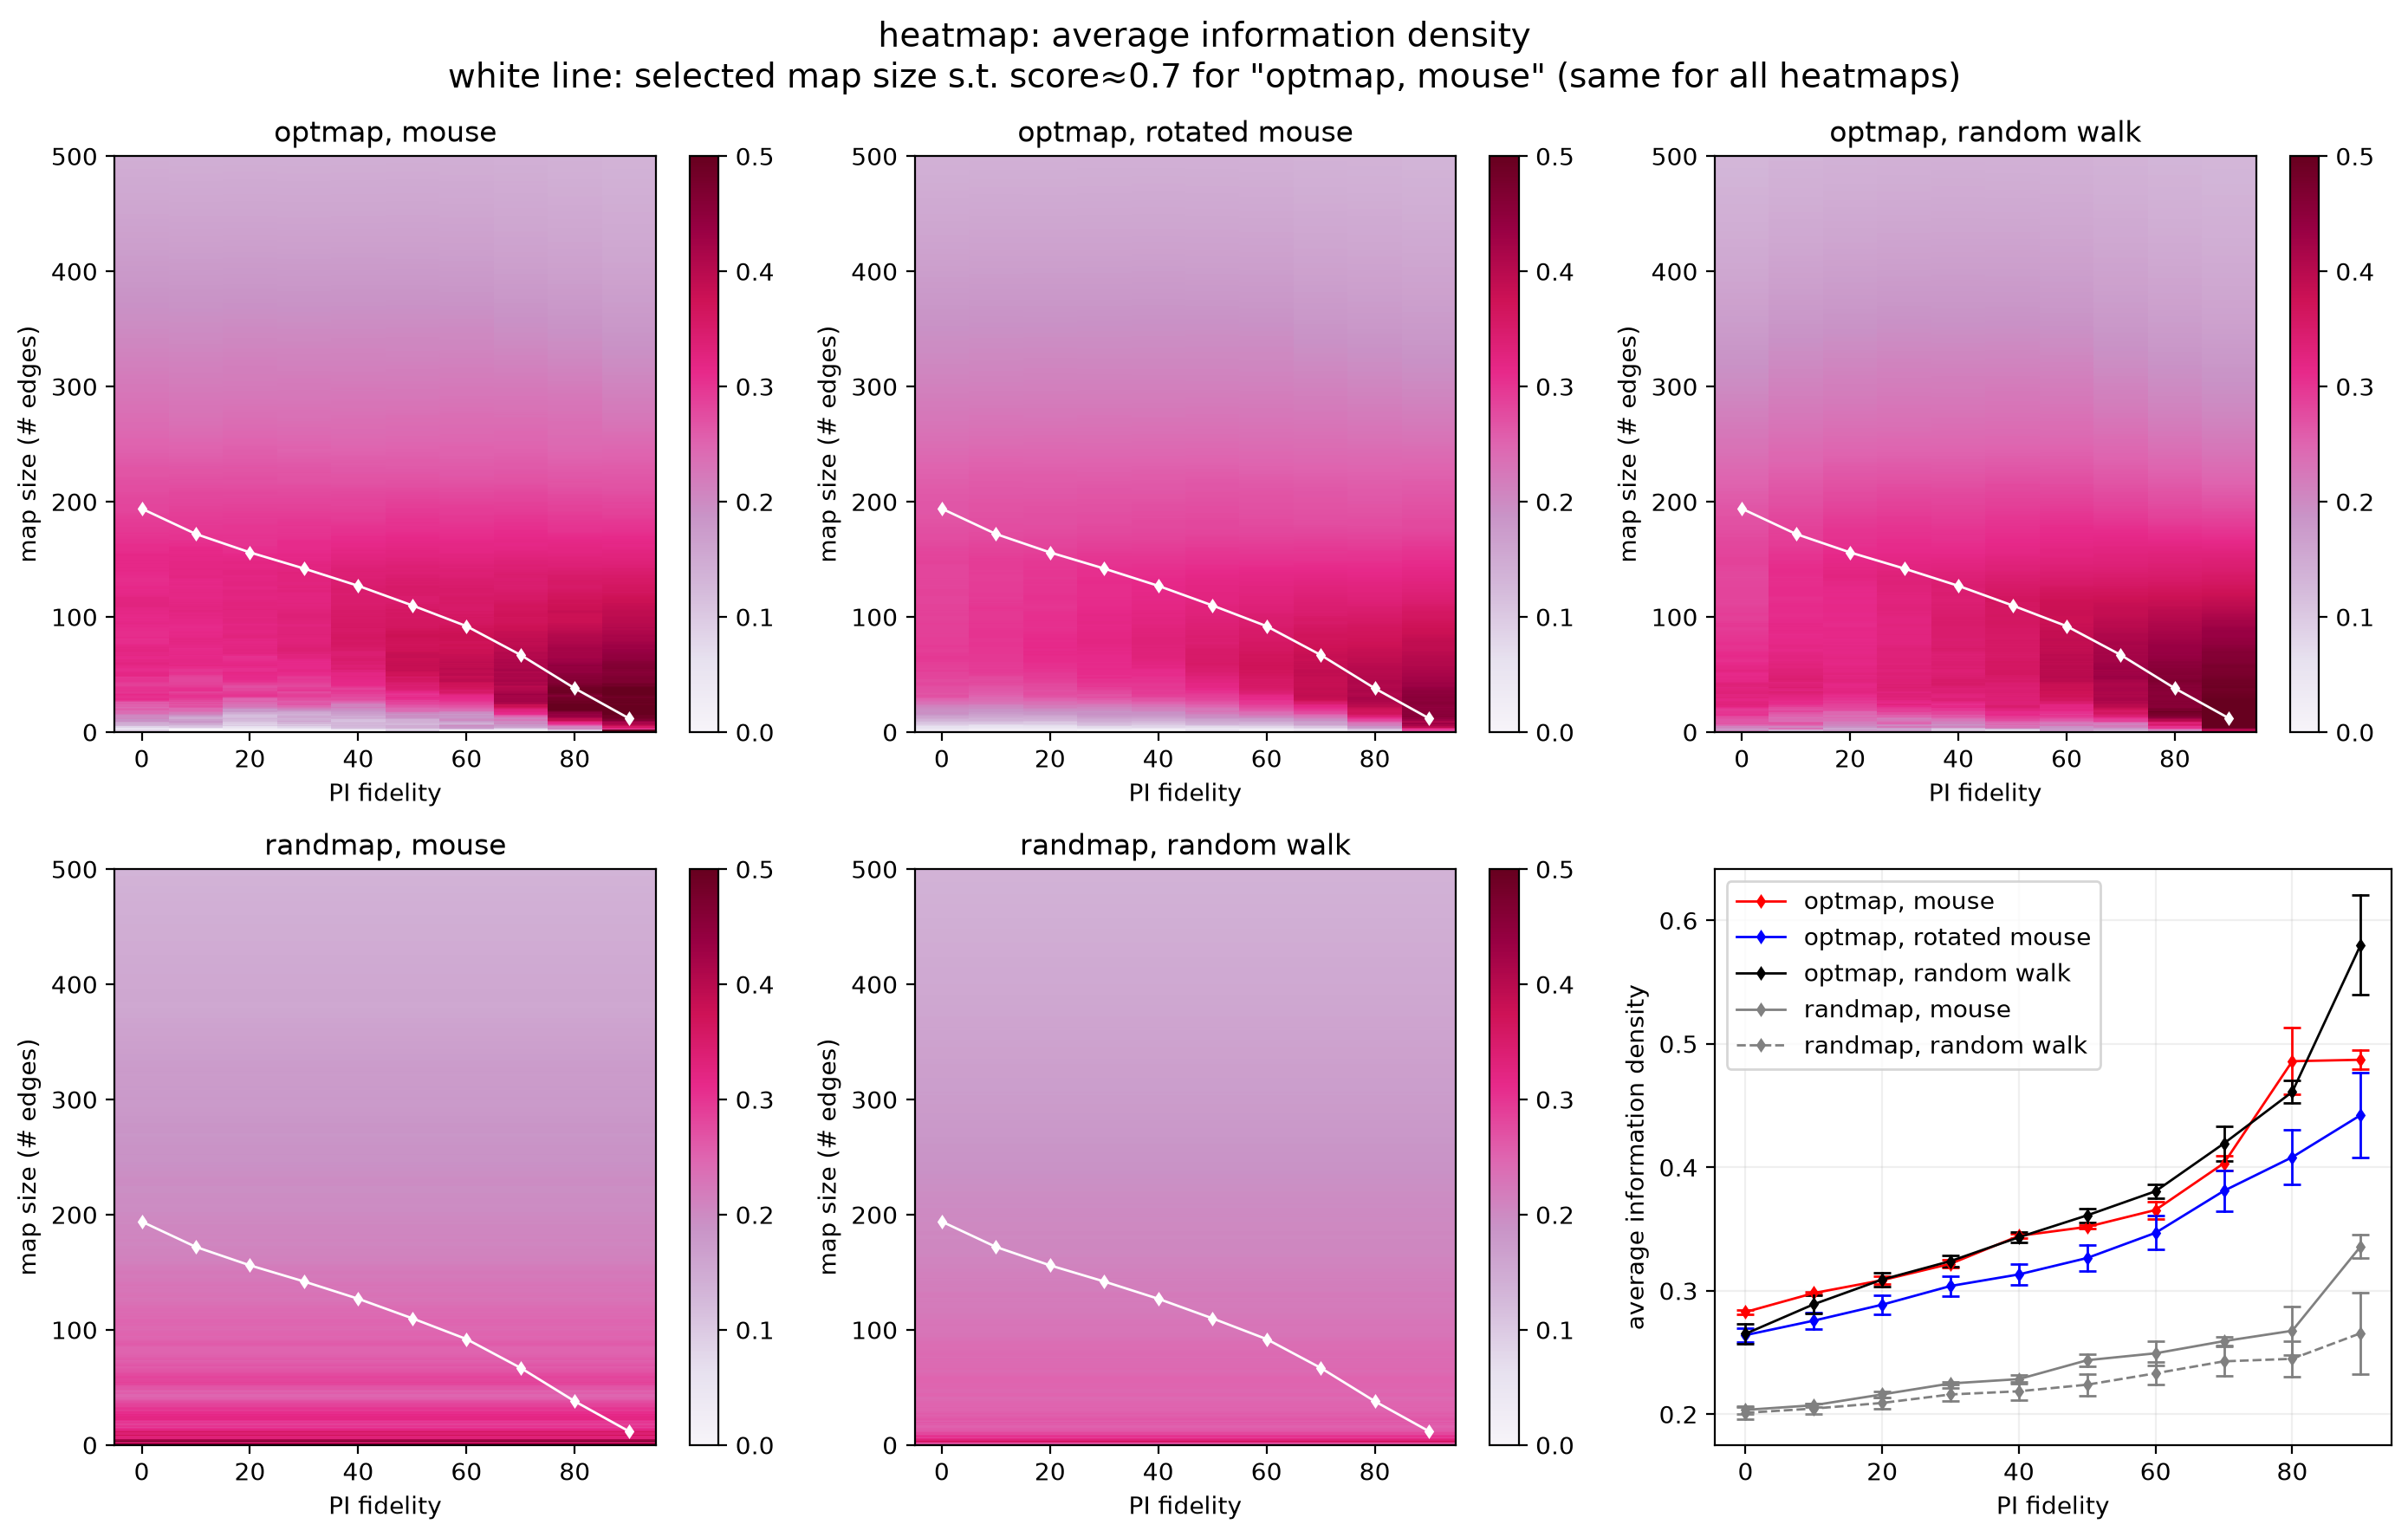

In [27]:
plt.figure(figsize=(14, 9), dpi=200)

# heatmap
plt.suptitle(f'heatmap: average information density\nwhite line: selected map size s.t. score≈{score_tar} for "{label_list[0]}" (same for all heatmaps)', fontsize=14)
for i, (label, info_mean) in enumerate(zip(label_list, info_mean_list)):
    plt.subplot(2, 3, i+1)
    plt.title(f'{label}')

    # heatmap
    plt.imshow(info_mean.T, aspect='auto', cmap='PuRd', interpolation='nearest', origin='lower', vmin=0, vmax=.5, extent=[pi_level_list[0]-5, pi_level_list[-1]+5, 0, info_mean.shape[1]])
    plt.colorbar()

    # curve
    plt.plot(pi_level_list, mapsize_list, c='w', lw=1, marker='d', markersize=3)

    # setting
    plt.ylim([0, 500])
    plt.xlabel('PI fidelity')
    plt.ylabel('map size (# edges)')

# summary
plt.subplot(2, 3, 6)
color_list = ['r','b','k','gray','gray']
linestyle_list = ['-', '-', '-', '-', '--']
for label, info_mean, info_ci, color, linestyle in zip(label_list, info_mean_list, info_ci_list, color_list, linestyle_list):
    info_mean_ = info_mean[np.arange(10), mapsize_list]
    info_ci_ = info_ci[np.arange(10), mapsize_list]

    plt.plot(pi_level_list, info_mean_, color=color, linestyle=linestyle, lw=1, marker='d', markersize=3, label=label)
    for pi, ci0, ci1 in zip(pi_level_list, info_mean_-info_ci_, info_mean_+info_ci_):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, info_mean_-info_ci_, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, info_mean_+info_ci_, color=color, s=50, marker='_', lw=1)
        
    # plt.axhline(0, color='gray', linestyle='--', lw=1)
    plt.xlabel('PI fidelity')
    plt.ylabel('average information density')
    plt.legend()
    plt.grid(alpha=.2)

# setting
plt.tight_layout()

### plot: summary

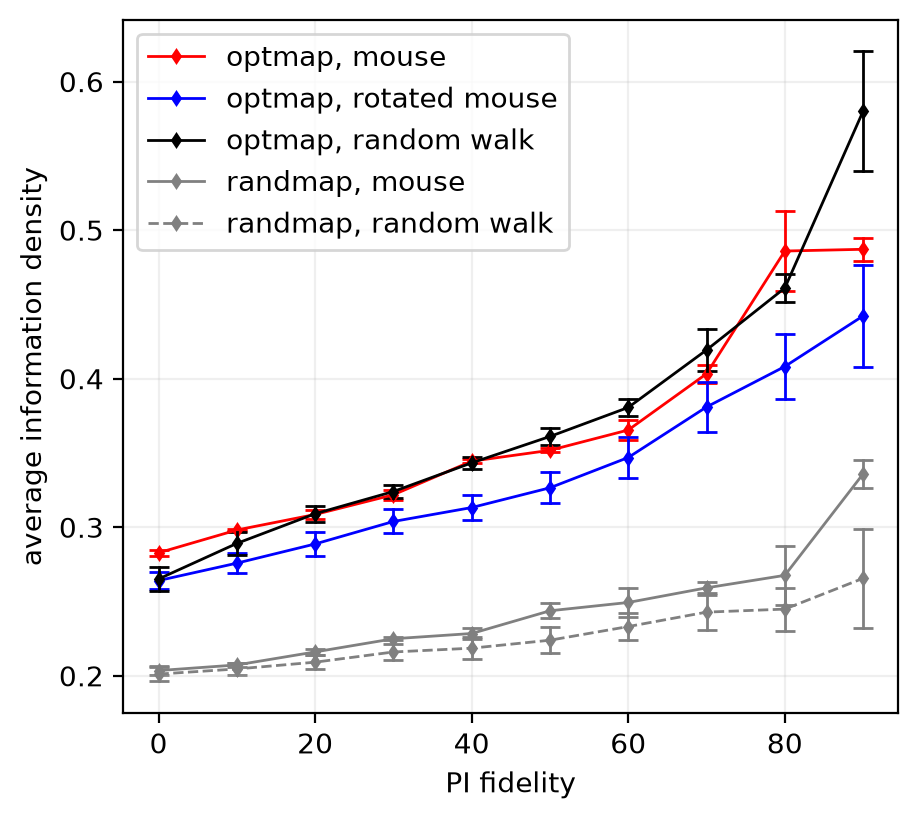

In [28]:
color_list = ['r','b','k','gray','gray']
linestyle_list = ['-', '-', '-', '-', '--']

# plot
plt.figure(figsize=(5,4.5), dpi=200)
for label, info_mean, info_ci, color, linestyle in zip(label_list, info_mean_list, info_ci_list, color_list, linestyle_list):
    info_mean_ = info_mean[np.arange(10), mapsize_list]
    info_ci_ = info_ci[np.arange(10), mapsize_list]

    plt.plot(pi_level_list, info_mean_, color=color, linestyle=linestyle, lw=1, marker='d', markersize=3, label=label)
    for pi, ci0, ci1 in zip(pi_level_list, info_mean_-info_ci_, info_mean_+info_ci_):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, info_mean_-info_ci_, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, info_mean_+info_ci_, color=color, s=50, marker='_', lw=1)
        
    # plt.axhline(0, color='gray', linestyle='--', lw=1)
    plt.xlabel('PI fidelity')
    plt.ylabel('average information density')
    plt.legend()
    plt.grid(alpha=.2)